<a href="https://colab.research.google.com/github/HieuStudyingCS/Learning-AI-Journey/blob/main/Gradient_descent_vs_Momentum_GD_NesterovGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import numpy as np
from numpy import linalg
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import random
import time

## Collect Data
In this section, we will test performance between two optimization algorithms Gradient Descent and Momentum-based Gradient Descent

(Sau này có thể phát triển dự án này hơn bằng cách để lại notes về lý thuyết và cách hiểu về 2 thuật toán, có thể benchmark thêm thuật Nesterov's Gradient Descent)

In [47]:
# Collect data
np.random.seed(42)

In [48]:
true_weight = 4.5
true_bias = 2.0
nb_samples = 1000
nb_features = 1

In [49]:
X = 2 * np.random.rand(nb_samples, nb_features)
X

array([[0.74908024],
       [1.90142861],
       [1.46398788],
       [1.19731697],
       [0.31203728],
       [0.31198904],
       [0.11616722],
       [1.73235229],
       [1.20223002],
       [1.41614516],
       [0.04116899],
       [1.9398197 ],
       [1.66488528],
       [0.42467822],
       [0.36364993],
       [0.36680902],
       [0.60848449],
       [1.04951286],
       [0.86389004],
       [0.58245828],
       [1.22370579],
       [0.27898772],
       [0.5842893 ],
       [0.73272369],
       [0.91213997],
       [1.57035192],
       [0.39934756],
       [1.02846888],
       [1.18482914],
       [0.09290083],
       [1.2150897 ],
       [0.34104825],
       [0.13010319],
       [1.89777107],
       [1.93126407],
       [1.6167947 ],
       [0.60922754],
       [0.19534423],
       [1.36846605],
       [0.88030499],
       [0.24407647],
       [0.99035382],
       [0.06877704],
       [1.8186408 ],
       [0.51755996],
       [1.32504457],
       [0.62342215],
       [1.040

In [50]:
y = true_weight * X + true_bias + np.random.randn(1000, 1) #  y = 4.5 * X + 2 + noise
y

array([[5.54856207e+00],
       [9.22108440e+00],
       [8.96814333e+00],
       [7.99851210e+00],
       [3.96395821e+00],
       [4.48473141e+00],
       [3.35667466e+00],
       [1.02547654e+01],
       [7.33986939e+00],
       [6.71169227e+00],
       [2.61487867e+00],
       [1.09368764e+01],
       [9.76356260e+00],
       [2.63430342e+00],
       [2.55536816e+00],
       [4.70379344e+00],
       [4.69862503e+00],
       [7.40430858e+00],
       [5.91582354e+00],
       [4.65081840e+00],
       [8.44495986e+00],
       [2.73940002e+00],
       [4.72542261e+00],
       [4.83498130e+00],
       [5.67013363e+00],
       [8.75741153e+00],
       [4.01919781e+00],
       [6.14936132e+00],
       [8.58748725e+00],
       [1.52344641e+00],
       [7.28103202e+00],
       [3.09498605e+00],
       [4.03244222e+00],
       [1.07365246e+01],
       [1.17225328e+01],
       [7.79001576e+00],
       [5.00857419e+00],
       [3.76867982e+00],
       [8.24038123e+00],
       [7.02685282e+00],


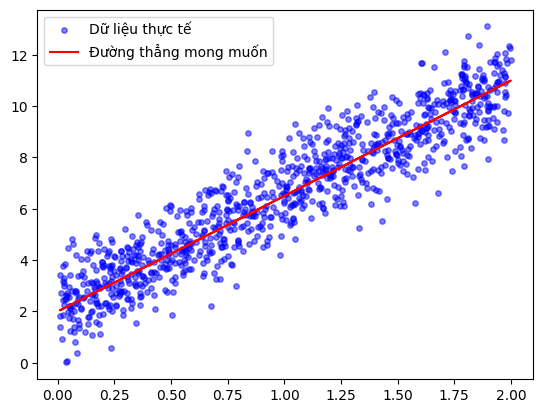

In [51]:
plt.scatter(X, y, color='blue', alpha=0.5, s=15, label='Dữ liệu thực tế')
plt.plot(X, true_weight * X + true_bias, color='red', label='Đường thẳng mong muốn')
plt.legend()
plt.show()

## Gradient Descent
### Đạo hàm của hàm một biến
- Gọi $x^{*}$ là điểm local minimum của hàm số, tức là $f'(x^{*}) = 0$.

- Ta thấy một đặc điểm đặc biệt là khi hàm số là đồng biến tại thời điểm $x_t$ (hay $f'(x_t) > 0$) thì $x_t$ luôn nằm về phía bên phải của điểm tối ưu $x^{*}$ và ngược lại
$$f'(x_t) > 0 = f'(x^{*}) \Rightarrow x_t > x^{*}$$   


Một cách tổng quát, ta giả sử $x_t$ nằm về phía phải của $x^{*}$ (hay $f'(x_t) > 0$)

- Nếu mục tiêu của ta là minimize loss function $\mathcal{L}(\mathbf{\theta})$ vậy thì để điểm tiếp theo $x_{t+1}$ gần với $x^{*}$ hơn thì ta cần di chuyển $x_t$ về phía bên trái (về phía âm) một lượng $\Delta$. Vậy ta có,
$$x_{t+1} = x_t + \Delta \tag{1}$$

Nhận xét:
- Vì hàm số đang là đồng biến, mà ta lại cần $x_t$ di chuyển về phía bên trái (tức là theo chiều âm) vậy thì xét về hướng, $\Delta$ là ngược hướng với đạo hàm tại $x_t$
- Nhận thấy, khi $x_t$ càng xa điểm tối ưu $x^{*}$ về phía bên phải thì để $x_{t+1}$ gần với $x^{*}$ thì $\Delta$ phải càng lớn. Hơn nữa, nếu $x_t$ càng xa $x^{*}$ về phía bên phải thì khi đó đạo hàm tại điểm $x_t$ cũng càng lớn.

Từ 2 nhận xét trên ta rút ra kết luận: $\Delta$ là một đại lượng ngược hướng và có độ lớn tỉ lệ thuận với độ lớn của đạo hàm tại điểm $x_t$.

$$\Delta = - f'(x_t) \tag{2}$$


Từ (1) và (2), ta rút ra công thức cập nhật $x_{t+1}$:
$$x_{t+1} = x_t - \eta f'(x_t)$$

Trong đó, $\eta$ là một số dương được gọi là **Learning Rate** để điều chỉnh độ lớn của đạo hàm trước khi cập nhật, tránh việc cập nhật quá đà sẽ nhảy vọt qua khỏi điểm tối ưu $x^{*}$

Ta cũng để ý một điều nữa đó là khi cập nhật $x_{t+1}$ thì ta hoàn toàn đi ngược hướng với đạo hàm, do vậy mới có cái tên Gradient Descent

### Đạo hàm cho hàm nhiều biến
Một cách tương tự ta thu được công thức cập nhật:
$$\theta_{t+1} = \theta_t - \eta \nabla_{\theta}f(\theta_t)$$

In [52]:
def graient(w_0, w_1, x):
  return w_0

In [53]:
def loss_function(y_pred, y):
  return np.mean((y_pred  - y)**2)

In [54]:
def gradient_descent(X, y, eta=0.01):
  w = np.zeros((X.shape[1], 1))
  loss_history = []
  N = X.shape[0]
  w_0 = 0
  nb_iterations = 0
  bias_history = [float(w_0)]
  w_history = [float(w[0][0])]

  for _ in range(100000):
    nb_iterations += 1
    y_pred = np.dot(X, w) + w_0
    loss = loss_function(y_pred, y)
    loss_history.append(loss)
    dw = (2 / N) * np.dot(X.T, (y_pred - y))
    db = (2 / N) * np.sum(y_pred - y)

    if(loss < 1e-4): break
    if len(loss_history) > 1 and abs(loss_history[-1] - loss_history[-2]) < 1e-9: break

    w -= eta*dw
    w_0 -= eta*db
    bias_history.append(float(w_0))
    w_history.append(float(w[0][0]))

  return w, w_0, loss_history, nb_iterations, w_history, bias_history

In [55]:
w_gd, b_gd, loss_gd, nb_iterations_GD, w_history_GD, bias_history_GD = gradient_descent(X, y, eta=0.01)
print(f"Trọng số thực tế: w={4.5}, b={2.0}")
print(f"GD tìm được: w={w_gd[0][0]:.3f}, b={b_gd:.3f}")
print(f'Số lượng bước GD: {nb_iterations_GD}')

Trọng số thực tế: w=4.5, b=2.0
GD tìm được: w=4.422, b=2.176
Số lượng bước GD: 2236


In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Momentum-based Gradient Descent


Có thể hình dung thuật toán này như sau

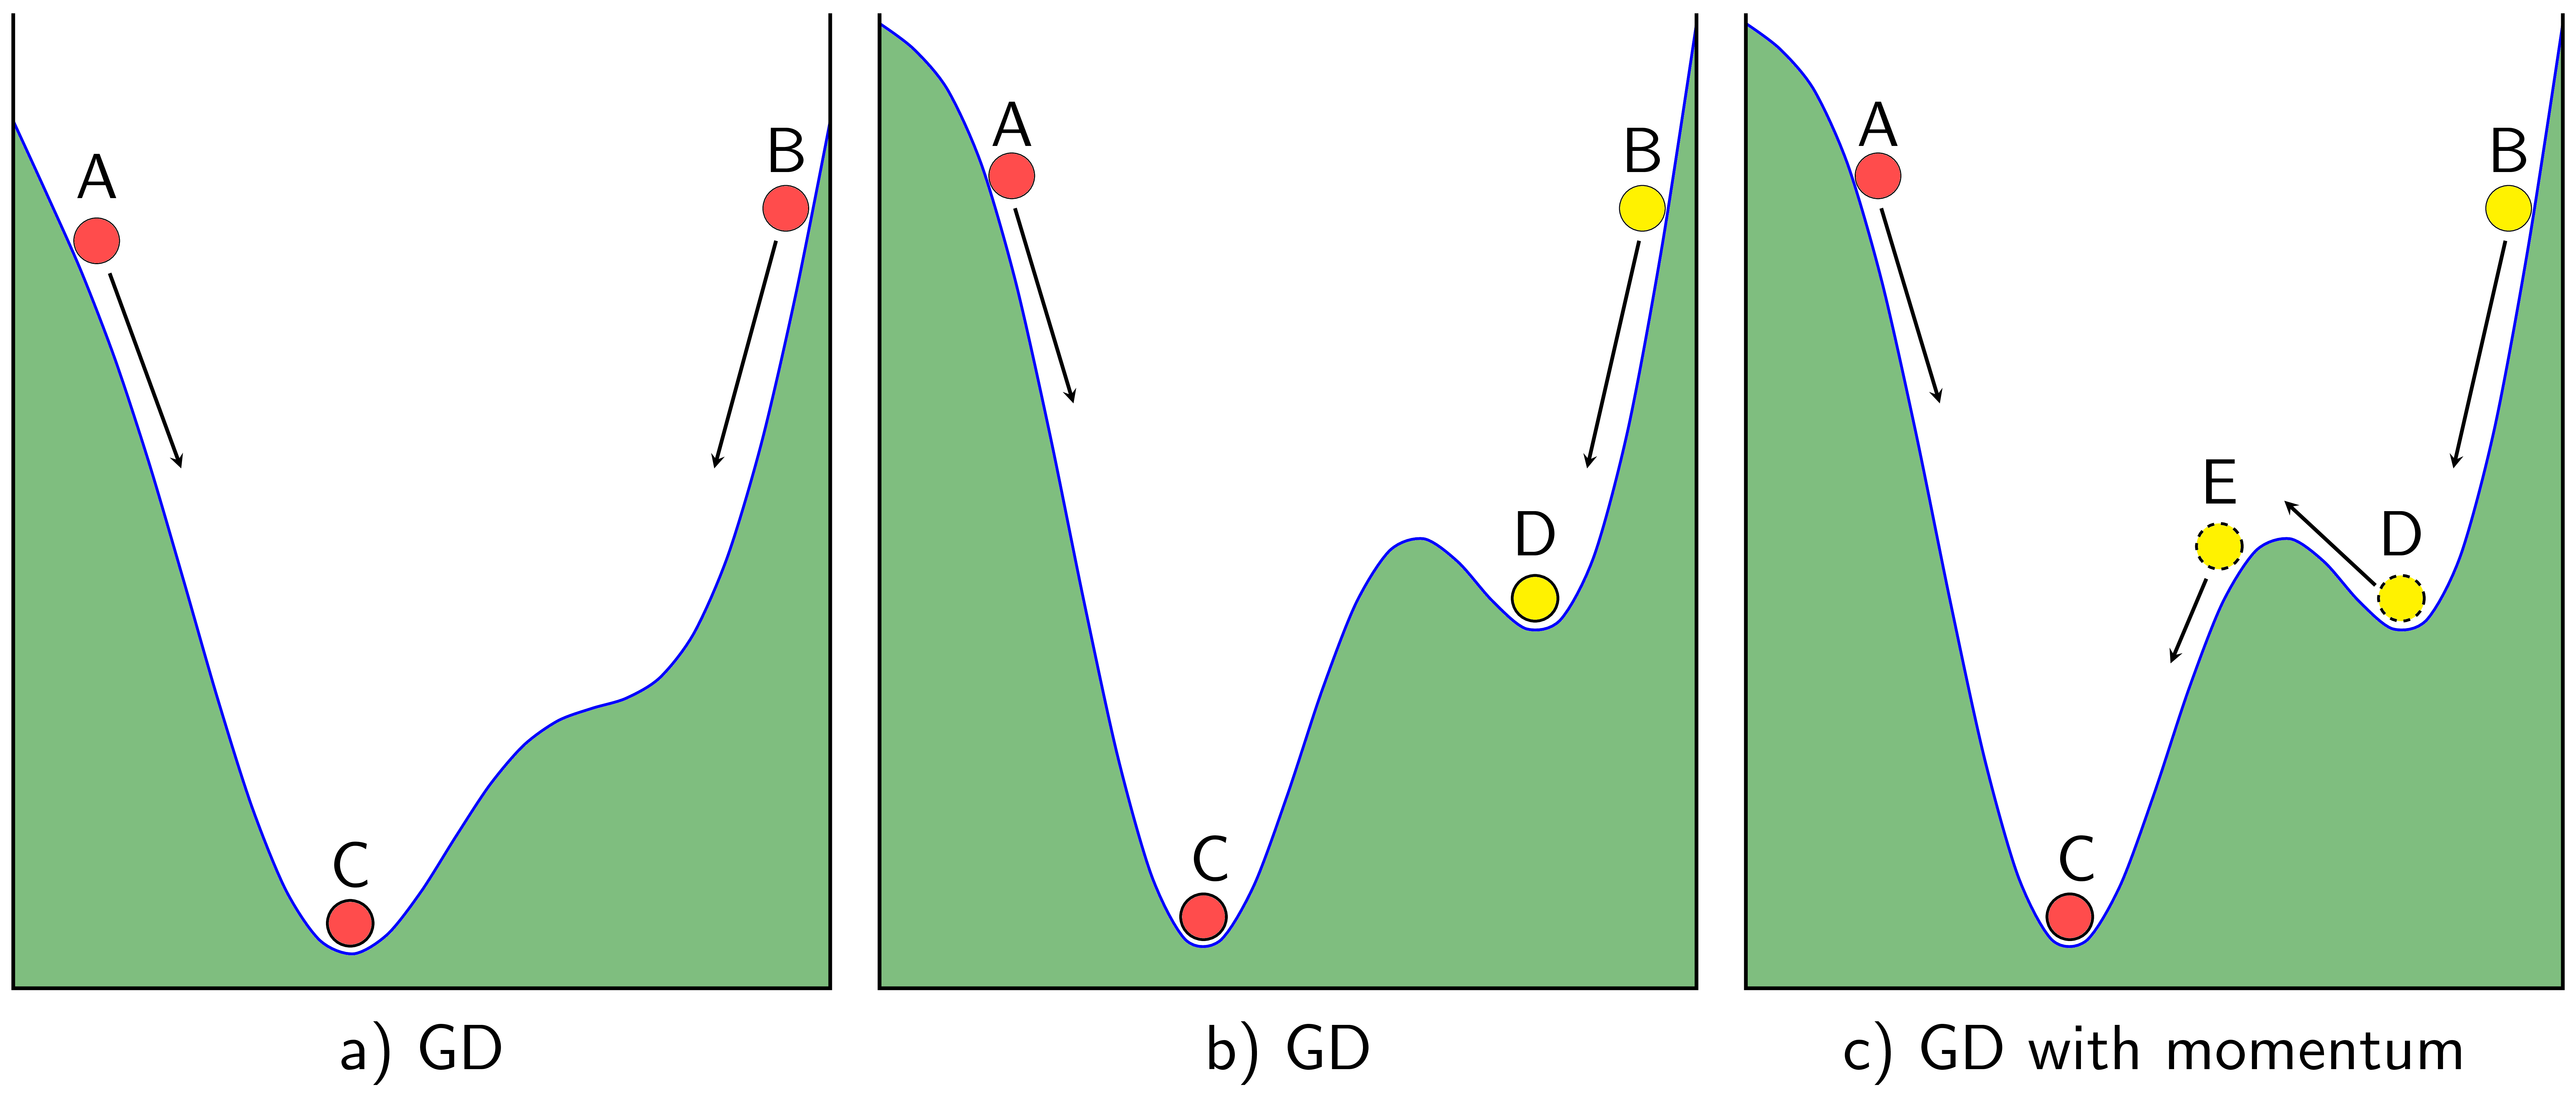

In [57]:
from IPython.display import Image, display

file_path = '/content/drive/MyDrive/momentum.png'

display(Image(filename=file_path, width=600))

Bức ảnh trên mô tả hình ảnh thung lũng (ta giả sử đó là đồ thị của hàm số mà ta cần tối ưu), và các viên bi được thả tại các điểm bất kỳ ở phía sườn phải hoặc trái của thung lũng (đây là các điểm chưa tối ưu). Nhiệm vụ của chúng ta là khiến cho viên bi lăn từ sườn dốc xuống tới đáy thung lũng (là điểm tối ưu - vị trí mà hàm số đạt cực tiểu).

- Trong hình a, rất dễ thấy sườn thung lũng rất thoải, do vậy mà dù ta thả viên bi từ bất kỳ điểm nào (A hay B) ta cũng đều thấy viên bi cùng đi về phía đáy thung lũng.
- Nhưng nếu ta thay đổi hình thung lũng này sang hình b, không khó để thấy nếu thả từ A thì viên bi tiến dần về phía điểm C. Ngược lại, khi thả ở B, có rất nhiều khả năng viên bi chỉ dừng lại tại D mà không thể tiến được đến C.

Tuy nhiên, trong một số trường hợp, nếu vận tốc tại B là rất lớn, viên bi sau khi rớt xuống điểm D, nó tận dụng **đà** để leo lên dốc tới điểm E và sau đó rớt xuống C.

Đây cũng là ý tưởng chính của Momentum Gradient Descent:

Gọi $v_t$ là vận tốc tại thời điểm $t$ (hay có thể hiểu là tốc độ thay đổi của hàm số tại thời điểm $t$), ta thấy công thức cập nhật (theo Gradient Descent) vẫn sẽ là $\theta_{t+1} = \theta_t - v_t$

Vậy thì việc của ta chính là đi tính xem $v_t$ này sẽ thế nào khi đã biết 2 tính chất như sau:
- $v_t$ cần mang theo thông tin của độ dốc của hàm số tại thời điểm $t$
- $v_t$ cần mang theo thông tin của vận tốc trước đó (nhưng bị hao hụt đi một phần)

Phương pháp đó là ta cộng cả 2 lại với nhau như sau:
$$v_t = \gamma v_{t-1} + \eta \nabla_{\theta}\mathcal{L}(\mathbf{\theta})$$

In [58]:
def momentum_gradient_descent(X, y, gamma=0.9, eta=0.01):
    w = np.zeros((X.shape[1], 1))
    loss_history = []
    N = X.shape[0]
    w_0 = 0
    nb_iterations = 0

    v_w = np.zeros((X.shape[1], 1))
    v_w0 = 0
    bias_history = [float(w_0)]
    w_history = [float(w[0][0])]

    for _ in range(100000):
        nb_iterations += 1

        y_pred = np.dot(X, w) + w_0
        loss = loss_function(y_pred, y)
        loss_history.append(loss)

        dw = (2 / N) * np.dot(X.T, (y_pred - y))
        db = (2 / N) * np.sum(y_pred - y)

        if (loss < 1e-4):
            break
        if len(loss_history) > 1 and abs(loss_history[-1] - loss_history[-2]) < 1e-9: break

        v_w = gamma * v_w + eta * dw
        v_w0 = gamma * v_w0 + eta * db

        w -= v_w
        w_0 -= v_w0
        bias_history.append(float(w_0))
        w_history.append(float(w[0][0]))

    return w, w_0, loss_history, nb_iterations, w_history, bias_history

### Ưu và Nhược điểm của Momentum Gradient Descent
- Ưu: tối ưu số lượng vòng lặp cần để thuật toán hội tụ (xem ví dụ thực nghiệm bên dưới). Giải quyết được vấn đề cập nhật chậm chạp và có khả năng rất cao rớt vào các điểm local minimum của thuật toán Gradient Descent
- Nhược: vì ta cộng thêm một lượng $v_{t-1}$ (hay vận tốc trước đó) vào công thức cập nhật $v_t$, nên nếu $v_{t-1}$ là rất lớn (tức là đà rất lớn) thì sẽ khiến cho $v_t$ tăng cao. Kết quả là đôi khi thuật toán sẽ nhảy thẳng từ bên phía dốc bên này sang phía dốc bên kia (nhảy qua cả global minimum) chỉ vì đà quá lớn.

Vì vậy ta mới có thêm thuật toán tên là Nesterov's Accelerated Gradient Descent để giải quyết vấn đề đà quá lớn này.

## So sánh tổng số bước trước khi hội tụ của Gradient Descent và Momentum Gradient Descent

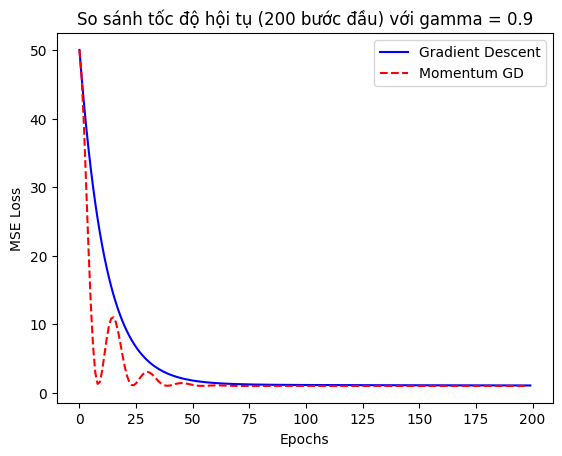

Trọng số thực tế: w=4.5, b=2.0
GD tìm được: w=4.422, b=2.176
Momentum tìm được: w=4.423, b=2.175
Số lượng bước GD: 2236
Số lượng bước Momentum GD: 199


In [59]:
# Gamma = 0.9
w_gd, b_gd, loss_gd, nb_iterations_GD, w_history_GD, bias_history_GD = gradient_descent(X, y, eta=0.01)
w_mom, b_mom, loss_mom, nb_iterations_MGD, w_history_MGD, bias_history_MGD = momentum_gradient_descent(X, y, eta=0.01, gamma=0.9)

plt.plot(loss_gd[:200], label='Gradient Descent', color='blue')
plt.plot(loss_mom[:200], label='Momentum GD', color='red', linestyle='--')

plt.title(f'So sánh tốc độ hội tụ (200 bước đầu) với gamma = 0.9')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

print(f"Trọng số thực tế: w={4.5}, b={2.0}")
print(f"GD tìm được: w={w_gd[0][0]:.3f}, b={b_gd:.3f}")
print(f"Momentum tìm được: w={w_mom[0][0]:.3f}, b={b_mom:.3f}")
print(f'Số lượng bước GD: {nb_iterations_GD}')
print(f'Số lượng bước Momentum GD: {nb_iterations_MGD}')

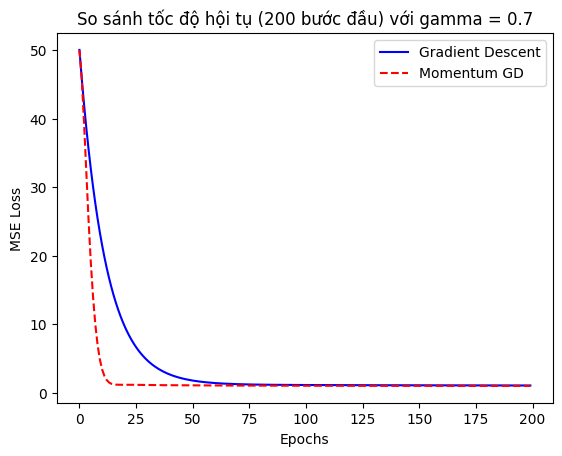

Trọng số thực tế: w=4.5, b=2.0
GD tìm được: w=4.422, b=2.176
Momentum tìm được: w=4.422, b=2.175
Số lượng bước GD: 2236
Số lượng bước Momentum GD: 711


In [60]:
# Gamma = 0.7
w_gd, b_gd, loss_gd, nb_iterations_GD, w_history_GD, bias_history_GD = gradient_descent(X, y, eta=0.01)
w_mom, b_mom, loss_mom, nb_iterations_MGD, w_history_MGD, bias_history_MGD = momentum_gradient_descent(X, y, eta=0.01, gamma=0.7)

plt.plot(loss_gd[:200], label='Gradient Descent', color='blue')
plt.plot(loss_mom[:200], label='Momentum GD', color='red', linestyle='--')

plt.title(f'So sánh tốc độ hội tụ (200 bước đầu) với gamma = 0.7')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

print(f"Trọng số thực tế: w={4.5}, b={2.0}")
print(f"GD tìm được: w={w_gd[0][0]:.3f}, b={b_gd:.3f}")
print(f"Momentum tìm được: w={w_mom[0][0]:.3f}, b={b_mom:.3f}")
print(f'Số lượng bước GD: {nb_iterations_GD}')
print(f'Số lượng bước Momentum GD: {nb_iterations_MGD}')

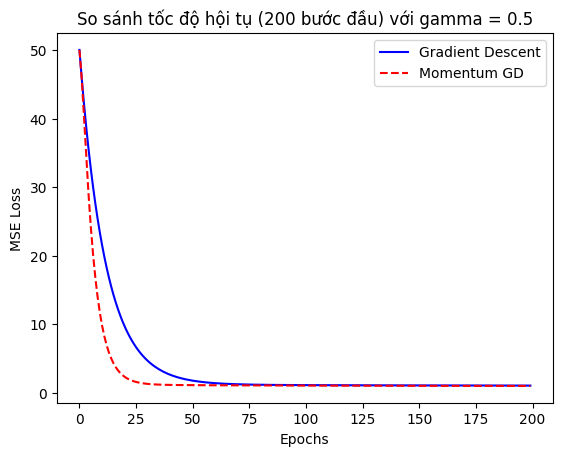

Trọng số thực tế: w=4.5, b=2.0
GD tìm được: w=4.422, b=2.176
Momentum tìm được: w=4.422, b=2.175
Số lượng bước GD: 2236
Số lượng bước Momentum GD: 1166


In [61]:
# Gamma = 0.5
w_gd, b_gd, loss_gd, nb_iterations_GD, w_history_GD, bias_history_GD = gradient_descent(X, y, eta=0.01)
w_mom, b_mom, loss_mom, nb_iterations_MGD, w_history_MGD, bias_history_MGD = momentum_gradient_descent(X, y, eta=0.01, gamma=0.5)

plt.plot(loss_gd[:200], label='Gradient Descent', color='blue')
plt.plot(loss_mom[:200], label='Momentum GD', color='red', linestyle='--')

plt.title(f'So sánh tốc độ hội tụ (200 bước đầu) với gamma = 0.5')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

print(f"Trọng số thực tế: w={4.5}, b={2.0}")
print(f"GD tìm được: w={w_gd[0][0]:.3f}, b={b_gd:.3f}")
print(f"Momentum tìm được: w={w_mom[0][0]:.3f}, b={b_mom:.3f}")
print(f'Số lượng bước GD: {nb_iterations_GD}')
print(f'Số lượng bước Momentum GD: {nb_iterations_MGD}')

## Nesterov accelerated gradient descent

Ý tưởng chính của thuật toán này là dự đoán trước hướng đi tương lai

Nhìn lại công thức cập nhật $v_t$ của Momentum Gradient Descent:
$$v_t = \gamma v_{t-1} + \eta \nabla_{\theta}\mathcal{L}(\theta)$$

Vấn đề đối với Momentum Gradient Descent như đã nói đó là vận tốc trước đó quá lớn nên mới dẫn tới hiện tượng đi sượt qua optimal point. Vậy nếu muốn viên bi không đi sượt qua optimal point, ta chỉ cần giảm lại $v_t$ (tức động lượng) là xong. Nên ta có một nhận xét nhỏ sau đây:
- Các siêu tham số như $\gamma$ và $\eta$ là hằng số cố định được thiết lập từ trước khi train nên đây là thành phần không thể giảm thiểu độ lớn.
- $v_{t-1}$ cũng là hằng số vì ta đã tính giá trị này trong lần lặp trước đó, qua tới vòng lặp này ta cũng không thể giảm thiểu nó đi được, và nếu muốn giảm đi thì giảm thế nào? Giảm bao nhiêu? Làm sao để xây dựng được cơ sở lý thuyết để biết được giảm đi bao nhiêu là hợp lí để thuật toán hội tụ tốt?

Qua 2 nhận xét trên thì một điều quá rõ ràng là nếu muốn giảm thiểu độ lớn của $v_t$, ta cần giảm đi Gradient, vậy thì câu hỏi đặt ra là giảm đi bao nhiêu? Giảm thế nào?

Nhìn qua ví dụ sau đây là hiểu:


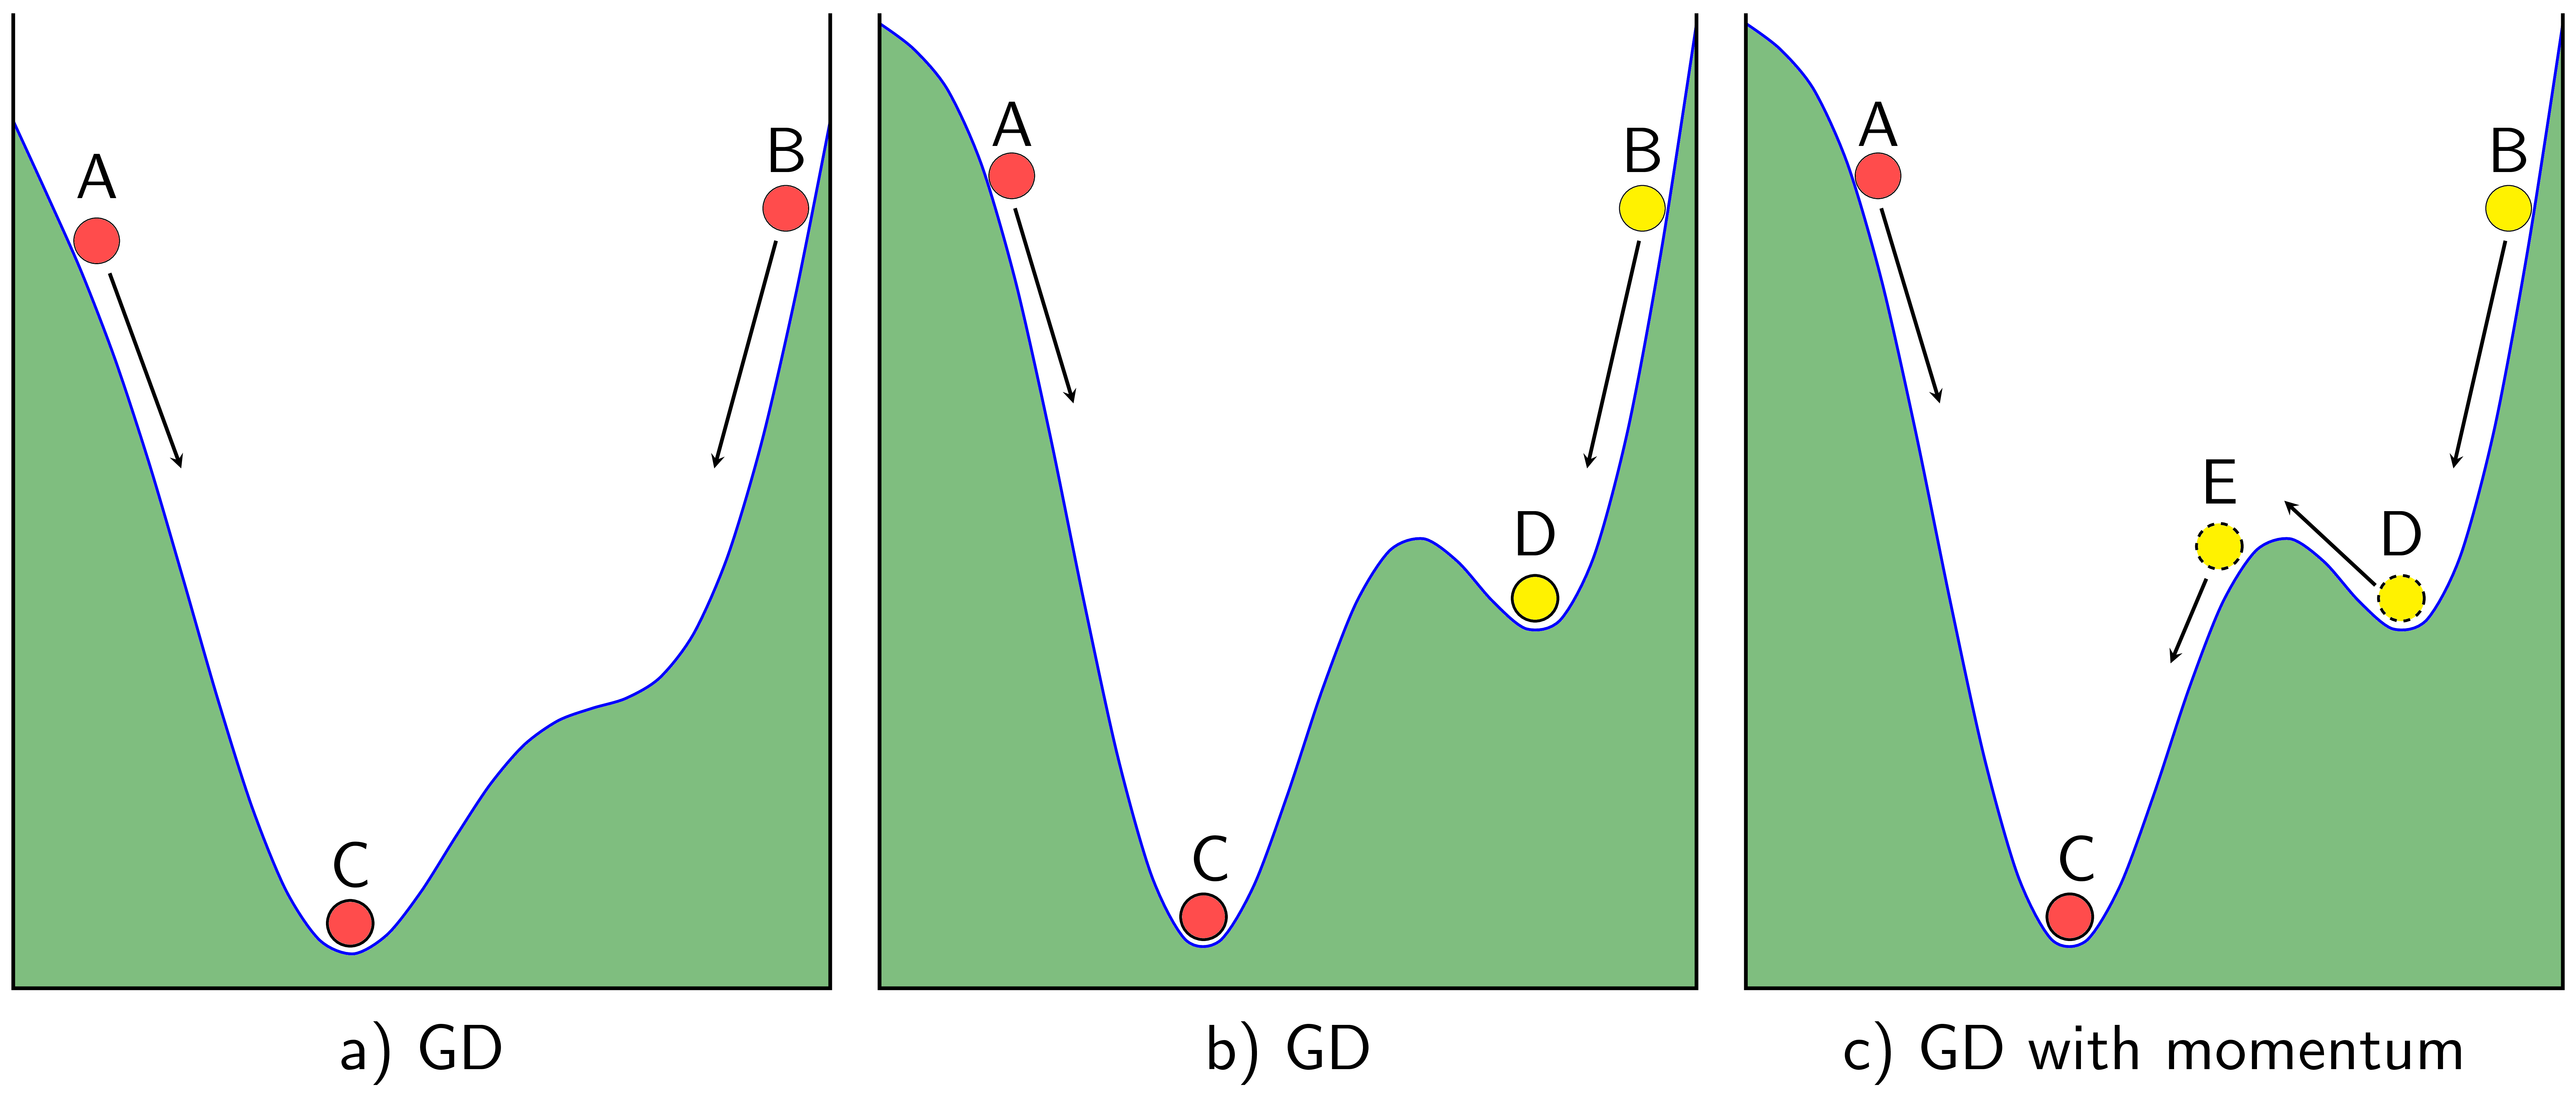

In [62]:
file_path = '/content/drive/MyDrive/momentum.png'
display(Image(filename=file_path, width=600))

Quay trở lại hình a:
- Giả sử ta thả viên bi tại A và mục tiêu là để thuật toán hội tụ tại C.
- Nhưng vì đà đi quá lớn và độ dốc lại quá cao, dẫn tới viên bi bị văng ngược lên lại điểm B (điểm cập nhật tiếp theo, nói cách khác là điểm $\theta = \theta - \gamma v_{t-1}$) mà không hội tụ về lại C được.
- Giờ nhìn lại nguyên lý cập nhật vận tốc theo Momentum Gradient Descent là gì? Đó là ta lấy vận tốc trước đó cộng với độ dốc tại thời điểm $t$. Khi viên bi ở A, hàm số có đạo hàm là số âm, do vậy ta cần cập nhật Gradient đi theo hướng dương (tức là ngược hướng với đạo hàm theo Gradient Descent).
- Cộng một số dương ($\nabla_{\theta}$) vào một số dương (vận tốc trước đó $v_{t-1}$) sẽ khiến cho $v_t$ tăng lớn và có thể nhảy trực tiếp sang điểm B - là điểm cập nhật kế tiếp có giá trị $\theta = \theta - \gamma v_{t-1}$.
- Đạo hàm tại vị trí dự đoán B mang giá trị dương (do dốc đi lên). Khi đưa vào công thức cập nhật $v_t$, nó sẽ tạo ra một đại lượng âm và triệt tiêu bớt đà của $v_{t-1}$. Tránh được trường hợp đi sượt qua điểm tối ưu trong Momentum Gradient Descent.

Và đó cũng là ý tưởng chính của thuật toán Nesterov: cập nhật Gradient tại vị trí tiếp theo thay vì cập nhật ở thời điểm hiện tại. Điều này thường được nói theo thuật ngữ "lookahead" là nhìn trước tương lai.

$$v_t = \gamma v_{t-1} + \eta \nabla_{\theta}\mathcal{L}(\theta - \gamma v_{t-1})$$

Công thức cập nhật vector trọng số vẫn không đổi:
$$\theta = \theta - v_t$$

In [63]:
def nesterov_momentum_gradient_descent(X, y, gamma=0.9, eta=0.01):
  w = np.zeros((X.shape[1], 1))
  N = X.shape[0]
  v_w0, w_0 = 0, 0
  v_w = np.zeros((X.shape[1], 1))
  nb_iterations = 0
  loss_history = []
  bias_history = [float(w_0)]
  w_history = [float(w[0][0])]

  for _ in range(100000):
    nb_iterations += 1

    y_pred = np.dot(X, w) + w_0
    loss = loss_function(y_pred, y)

    loss_history.append(loss)

    if loss < 1e-4: break
    if len(loss_history) > 1 and abs(loss_history[-1] - loss_history[-2]) < 1e-9: break

    w_tmp = w - gamma * v_w
    w0_tmp = w_0 - gamma * v_w0

    y_pred_tmp = X @ w_tmp + w0_tmp
    dw_tmp = (2 / N) * np.dot(X.T, (y_pred_tmp - y))
    db_tmp = (2 / N) * np.sum(y_pred_tmp -y)

    v_w = gamma * v_w + eta * dw_tmp
    v_w0 = gamma * v_w0 + eta * db_tmp

    w -= v_w
    w_0 -= v_w0

    bias_history.append(float(w_0))
    w_history.append(float(w[0][0]))

  return w, w_0, loss_history, nb_iterations, w_history, bias_history

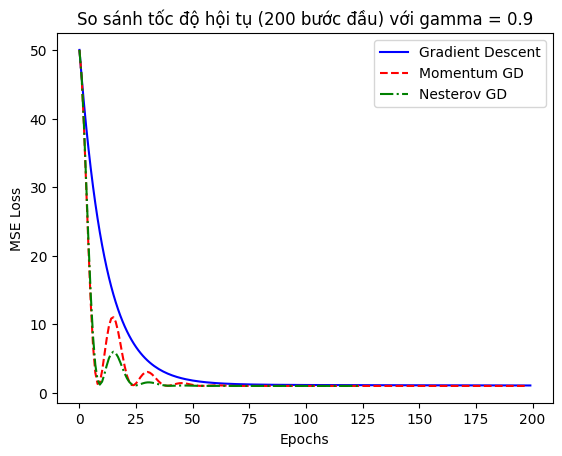

Trọng số thực tế: w={4.5}, b={2.0}
GD tìm được: w=4.422, b=2.176
Momentum tìm được: w=4.423, b=2.175
Nesterov tìm được: w=4.422, b=2.175
Số lượng bước GD: 2236
Số lượng bước Momentum: 199
Số lượng bước Nesterov: 124


In [64]:
w_gd, b_gd, loss_gd, iter_gd, w_history_GD, bias_history_GD = gradient_descent(X, y, eta=0.01)
w_mom, b_mom, loss_mom, iter_mom, w_history_MGD, bias_history_MGD = momentum_gradient_descent(X, y, eta=0.01, gamma=0.9)
w_nes, b_nes, loss_nes, iter_nes, w_history_nes, bias_history_nes = nesterov_momentum_gradient_descent(X, y, eta=0.01, gamma=0.9)

plt.plot(loss_gd[:200], label='Gradient Descent', color='blue')
plt.plot(loss_mom[:200], label='Momentum GD', color='red', linestyle='--')
plt.plot(loss_nes[:200], label='Nesterov GD', color='green', linestyle='-.')

plt.title('So sánh tốc độ hội tụ (200 bước đầu) với gamma = 0.9')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

print(f"Trọng số thực tế: w={{4.5}}, b={{2.0}}")
print(f"GD tìm được: w={w_gd[0][0]:.3f}, b={b_gd:.3f}")
print(f"Momentum tìm được: w={w_mom[0][0]:.3f}, b={b_mom:.3f}")
print(f"Nesterov tìm được: w={w_nes[0][0]:.3f}, b={b_nes:.3f}")
print(f"Số lượng bước GD: {iter_gd}")
print(f"Số lượng bước Momentum: {iter_mom}")
print(f"Số lượng bước Nesterov: {iter_nes}")

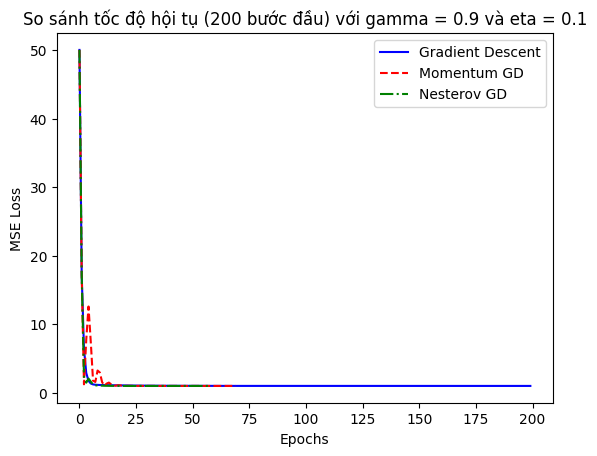

Trọng số thực tế: w={4.5}, b={2.0}
GD tìm được: w=4.422, b=2.175
Momentum tìm được: w=4.423, b=2.175
Nesterov tìm được: w=4.423, b=2.175
Số lượng bước GD: 258
Số lượng bước Momentum: 70
Số lượng bước Nesterov: 59


In [65]:
w_gd, b_gd, loss_gd, iter_gd, w_history_GD, bias_history_GD = gradient_descent(X, y, eta=0.1)
w_mom, b_mom, loss_mom, iter_mom, w_history_MGD, bias_history_MGD = momentum_gradient_descent(X, y, eta=0.1, gamma=0.7)
w_nes, b_nes, loss_nes, iter_nes, w_history_nes, bias_history_nes = nesterov_momentum_gradient_descent(X, y, eta=0.1, gamma=0.7)

plt.plot(loss_gd[:200], label='Gradient Descent', color='blue')
plt.plot(loss_mom[:200], label='Momentum GD', color='red', linestyle='--')
plt.plot(loss_nes[:200], label='Nesterov GD', color='green', linestyle='-.')

plt.title('So sánh tốc độ hội tụ (200 bước đầu) với gamma = 0.9 và eta = 0.1')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

print(f"Trọng số thực tế: w={{4.5}}, b={{2.0}}")
print(f"GD tìm được: w={w_gd[0][0]:.3f}, b={b_gd:.3f}")
print(f"Momentum tìm được: w={w_mom[0][0]:.3f}, b={b_mom:.3f}")
print(f"Nesterov tìm được: w={w_nes[0][0]:.3f}, b={b_nes:.3f}")
print(f"Số lượng bước GD: {iter_gd}")
print(f"Số lượng bước Momentum: {iter_mom}")
print(f"Số lượng bước Nesterov: {iter_nes}")

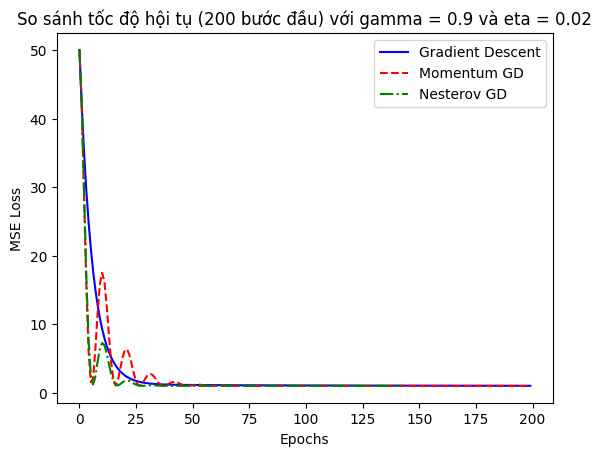

Trọng số thực tế: w={4.5}, b={2.0}
GD tìm được: w=4.422, b=2.175
Momentum tìm được: w=4.423, b=2.175
Nesterov tìm được: w=4.423, b=2.175
Số lượng bước GD: 1172
Số lượng bước Momentum: 202
Số lượng bước Nesterov: 143


In [66]:
w_gd, b_gd, loss_gd, iter_gd, w_history_GD, bias_history_GD = gradient_descent(X, y, eta=0.02)
w_mom, b_mom, loss_mom, iter_mom, w_history_MGD, bias_history_MGD = momentum_gradient_descent(X, y, eta=0.02, gamma=0.9)
w_nes, b_nes, loss_nes, iter_nes, w_history_nes, bias_history_nes = nesterov_momentum_gradient_descent(X, y, eta=0.02, gamma=0.9)

plt.plot(loss_gd[:200], label='Gradient Descent', color='blue')
plt.plot(loss_mom[:200], label='Momentum GD', color='red', linestyle='--')
plt.plot(loss_nes[:200], label='Nesterov GD', color='green', linestyle='-.')

plt.title('So sánh tốc độ hội tụ (200 bước đầu) với gamma = 0.9 và eta = 0.02')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

print(f"Trọng số thực tế: w={{4.5}}, b={{2.0}}")
print(f"GD tìm được: w={w_gd[0][0]:.3f}, b={b_gd:.3f}")
print(f"Momentum tìm được: w={w_mom[0][0]:.3f}, b={b_mom:.3f}")
print(f"Nesterov tìm được: w={w_nes[0][0]:.3f}, b={b_nes:.3f}")
print(f"Số lượng bước GD: {iter_gd}")
print(f"Số lượng bước Momentum: {iter_mom}")
print(f"Số lượng bước Nesterov: {iter_nes}")

## Contour và Animation cho cả 3 thuật toán
Các bạn tự chạy code tại đây vì mình ko bỏ lên github được do nặng quá :vvv

In [ ]:
from IPython.display import HTML, display
import matplotlib as mpl

_, _, _, _, w_hist_gd, b_hist_gd = gradient_descent(X, y, eta=0.1)
_, _, _, _, w_hist_mom, b_hist_mom = momentum_gradient_descent(X, y, eta=0.1, gamma=0.7)
_, _, _, _, w_hist_nes, b_hist_nes = nesterov_momentum_gradient_descent(X, y, eta=0.1, gamma=0.7)

w_vals = np.linspace(-1, 6, 100)
b_vals = np.linspace(-1, 4, 100)
W, B = np.meshgrid(w_vals, b_vals)
Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_pred_grid = X * W[i, j] + B[i, j]
        Z[i, j] = np.mean((y_pred_grid - y)**2)

fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contour(W, B, Z, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.5)
ax.plot(4.5, 2.0, 'k*', markersize=10, label='Global Minimum (4.5, 2.0)')

line_gd, = ax.plot([], [], 'b-', label='Gradient Descent', alpha=0.8)
line_mom, = ax.plot([], [], 'r--', label='Momentum GD', alpha=0.8)
line_nes, = ax.plot([], [], 'g-.', label='Nesterov GD', alpha=0.8)

point_gd, = ax.plot([], [], 'bo', markersize=4)
point_mom, = ax.plot([], [], 'ro', markersize=4)
point_nes, = ax.plot([], [], 'go', markersize=4)

ax.set_xlabel('Weight (w)')
ax.set_ylabel('Bias (b)')
ax.set_title('Optimization Trajectory')
ax.legend()

def init():
    line_gd.set_data([], [])
    line_mom.set_data([], [])
    line_nes.set_data([], [])
    point_gd.set_data([], [])
    point_mom.set_data([], [])
    point_nes.set_data([], [])
    return line_gd, line_mom, line_nes, point_gd, point_mom, point_nes

def update(frame):
    if frame < len(w_hist_gd):
        line_gd.set_data(w_hist_gd[:frame+1], b_hist_gd[:frame+1])
        point_gd.set_data([w_hist_gd[frame]], [b_hist_gd[frame]])

    if frame < len(w_hist_mom):
        line_mom.set_data(w_hist_mom[:frame+1], b_hist_mom[:frame+1])
        point_mom.set_data([w_hist_mom[frame]], [b_hist_mom[frame]])

    if frame < len(w_hist_nes):
        line_nes.set_data(w_hist_nes[:frame+1], b_hist_nes[:frame+1])
        point_nes.set_data([w_hist_nes[frame]], [b_hist_nes[frame]])

    ax.set_title(f'Trajectory Comparison - Iteration: {frame}')
    return line_gd, line_mom, line_nes, point_gd, point_mom, point_nes

max_frames = max(len(w_hist_gd), len(w_hist_mom), len(w_hist_nes))
frames_to_show = min(max_frames, 250)

ani = animation.FuncAnimation(fig, update, frames=frames_to_show, init_func=init, blit=True, interval=30)

mpl.rcParams['animation.embed_limit'] = 50.0

html_anim = HTML(ani.to_jshtml())
plt.close(fig)
display(html_anim)

## Kết luận và Một số điều đáng lưu ý
- Kết quả thực nghiệm với siêu tham số $\eta = 0.1$ và $\gamma = 0.7$ cho thấy sự phân hóa rõ rệt về chỉ số đo lường hiệu suất giữa các thuật toán.

### Chi tiết chỉ số hội tụ
- **Gradient Descent (GD)** truyền thống hội tụ sau $258$ bước lặp, giúp ta thu được $w=4.422$ và $b=2.175$.
- **Thuật toán Momentum** thu được $w=4.423$ và $b=2.175$ với $70$ bước lặp.
- **Thuật toán Nesterov Accelerated Gradient (NAG)** thu được kết quả thực nghiệm tương đương Momentum Gradient Descent $w=4.423$ và $b=2.175$ với $59$ bước lặp.

### Đánh giá thuật toán
- Về nghiệm: Có chênh lệch kết quả giữa các thuật toán chỉ ở mức $0.001$ đối với tham số $w$ và khớp nhau ở tham số $b$, lý do là cả ba thuật toán đều chạm tới điều kiện dừng sớm early stopping.
- Về số vòng lặp: Momentum giảm khoảng 73% số lần lặp, trong khi Nesterov giảm 77% so với Gradient Descent thông thường. Qua đó, có thể thấy khi thuật toán có sử dụng thêm động lượng sẽ giúp nó hội tụ với số lần lặp ít hơn, đỡ tiêu tốn tài nguyên tính toán hơn rất nhiều. Ngoài ra, đối với Nesterov, cơ chế tính toán gradient tại vị trí trong tương lai sẽ giúp mô hình tự biết điều chỉnh để tăng/giảm hợp lý, tránh tình trạng đi quá đà giống Momentum Gradient Descent, tối ưu thêm khoảng 15% số vòng lặp so với Momentum Gradient Descent.
- Về tài nguyên tính toán: Giảm số vòng lặp cũng tương đương với giảm thiểu số lượng phép tính đạo hàm trên toàn bộ tập dữ liệu. Mặc dù là mỗi vòng lặp của Momentum và Nesterov cần cấp phát thêm bộ nhớ cho mảng vận tốc và xử lý thêm các phép tính ma trận khác nhưng mức tiêu hao là không quá lớn so với chi phí tính toán đạo hàm.

### Kết luận chung
Có thể kết luận được rằng các kỹ thuật tối ưu gradient descent dựa vào động lượng (hay đà) mang lại kết quả tương tự nhưng tiêu tốn ít tài nguyên tính toán và số lần lặp hơn so với GD thông thường